In [1]:
import torch
print(torch.cuda.is_available())

True


# Skin Lesion Classification: Benign vs Malignant

**Student:** Diane Lenhoff  
**Course:** ITAI 1378 - Computer Vision and AI  
**Project Type:** Tier 1 Image Classification  

This project uses transfer learning with a pretrained ResNet18 model to classify skin lesion images as benign or malignant.

**Disclaimer:** This project is for educational purposes only and is not a medical diagnostic tool.

In [4]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [9]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [10]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("skin_cancer_data")

print("Dataset uploaded and extracted successfully!")

Dataset uploaded and extracted successfully!


In [11]:
for root, dirs, files in os.walk("skin_cancer_data"):
    print(root, "->", len(files), "files")

skin_cancer_data -> 0 files
skin_cancer_data/train -> 0 files
skin_cancer_data/train/benign -> 1440 files
skin_cancer_data/train/malignant -> 1197 files
skin_cancer_data/test -> 0 files
skin_cancer_data/test/benign -> 360 files
skin_cancer_data/test/malignant -> 300 files
skin_cancer_data/data -> 0 files
skin_cancer_data/data/train -> 0 files
skin_cancer_data/data/train/benign -> 1440 files
skin_cancer_data/data/train/malignant -> 1197 files
skin_cancer_data/data/test -> 0 files
skin_cancer_data/data/test/benign -> 360 files
skin_cancer_data/data/test/malignant -> 300 files


In [12]:
train_dir = "skin_cancer_data/train"
test_dir = "skin_cancer_data/test"

In [15]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['benign', 'malignant']
Training Images: 2637
Testing Images: 660


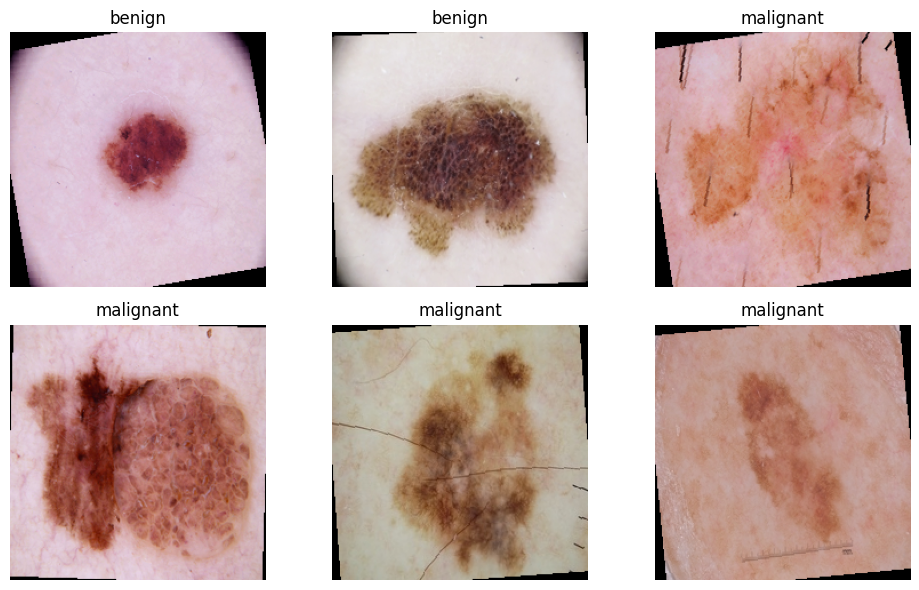

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    imshow(images[i], class_names[labels[i]])

plt.tight_layout()
plt.show()

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("ResNet18 model is ready.")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


ResNet18 model is ready.


In [18]:
num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.2f}%")

Epoch 1/5 | Loss: 0.4390 | Accuracy: 78.95%
Epoch 2/5 | Loss: 0.3484 | Accuracy: 83.01%
Epoch 3/5 | Loss: 0.3379 | Accuracy: 84.03%
Epoch 4/5 | Loss: 0.3120 | Accuracy: 85.21%
Epoch 5/5 | Loss: 0.2918 | Accuracy: 86.42%


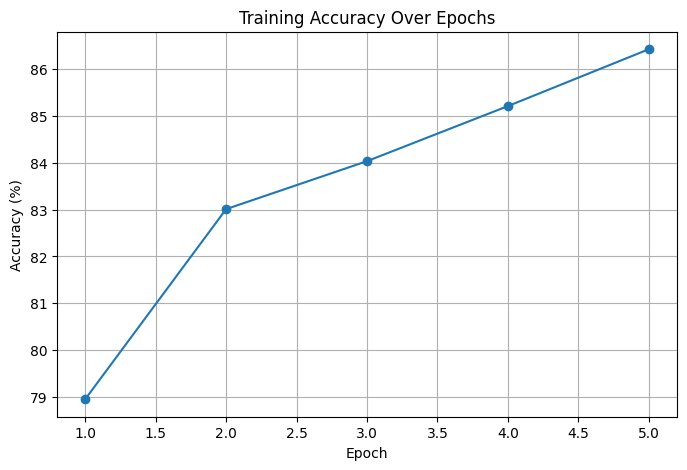

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

In [20]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 69.24%


In [21]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

extra_epochs = 5

for epoch in range(extra_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Extra Epoch {epoch+1}/{extra_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_accuracy:.2f}%")

Extra Epoch 1/5 | Loss: 0.2562 | Accuracy: 89.15%
Extra Epoch 2/5 | Loss: 0.2172 | Accuracy: 90.67%
Extra Epoch 3/5 | Loss: 0.1896 | Accuracy: 91.05%
Extra Epoch 4/5 | Loss: 0.1757 | Accuracy: 92.34%
Extra Epoch 5/5 | Loss: 0.1786 | Accuracy: 92.34%


In [22]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    correct = 0
    total = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 90.15%


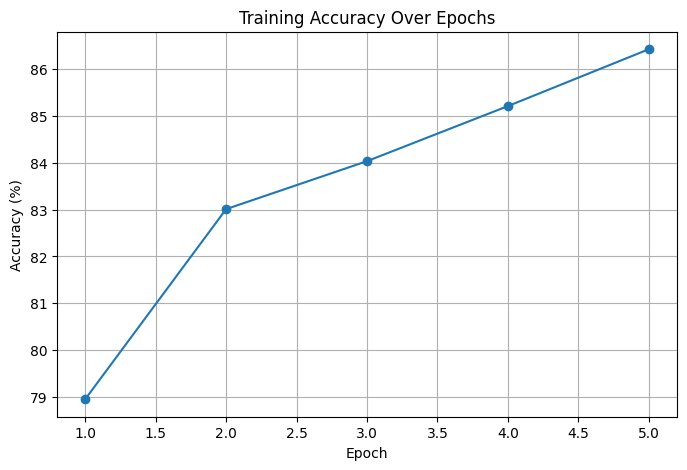

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()

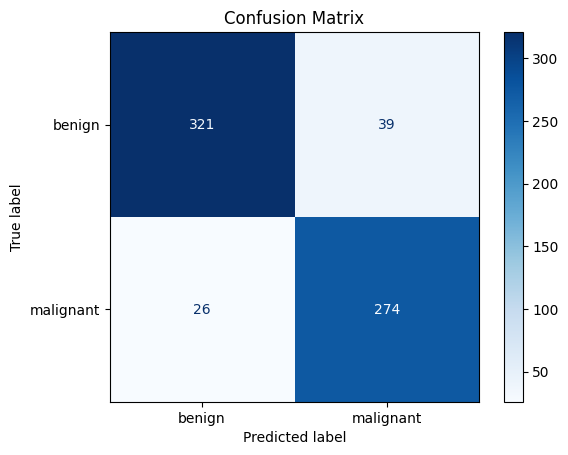

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

      benign       0.93      0.89      0.91       360
   malignant       0.88      0.91      0.89       300

    accuracy                           0.90       660
   macro avg       0.90      0.90      0.90       660
weighted avg       0.90      0.90      0.90       660



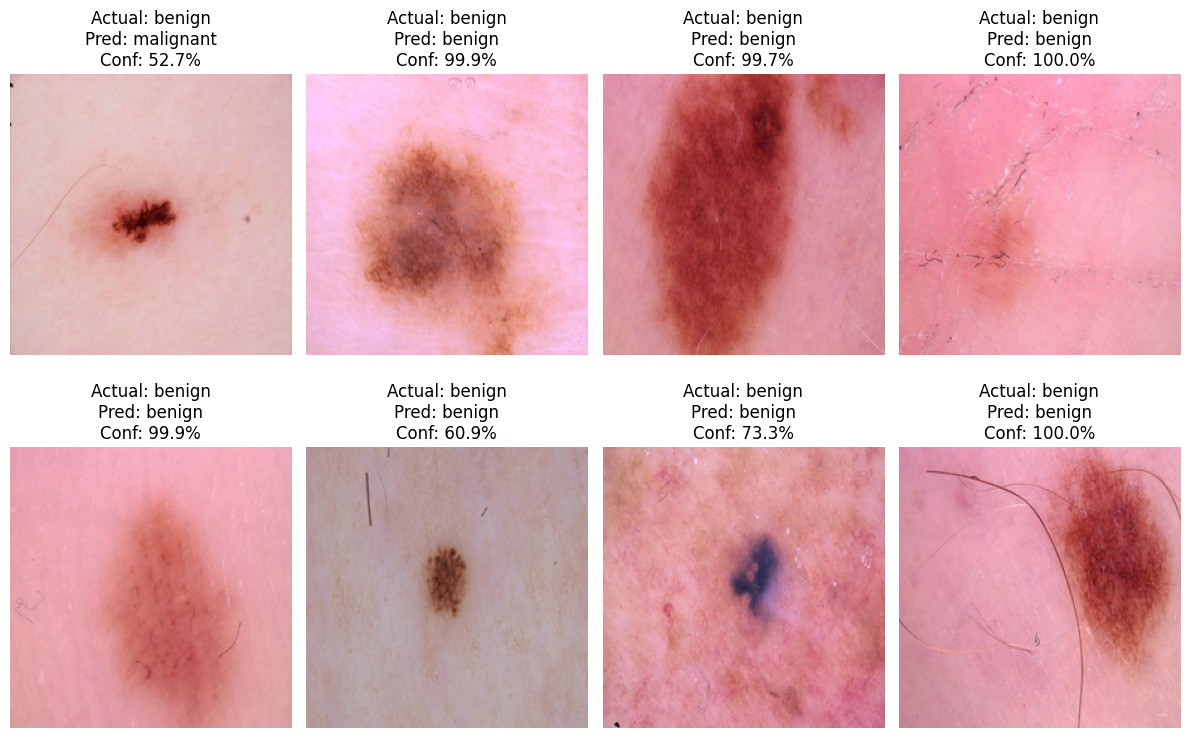

In [27]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predictions = torch.max(probabilities, 1)

images = images.cpu()
labels = labels.cpu()
predictions = predictions.cpu()
confidence = confidence.cpu()

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    img = images[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    actual = class_names[labels[i]]
    predicted = class_names[predictions[i]]
    conf = confidence[i].item() * 100

    plt.imshow(img)
    plt.title(f"Actual: {actual}\nPred: {predicted}\nConf: {conf:.1f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
torch.save(model.state_dict(), "skin_lesion_resnet18_model.pth")
print("Model saved as skin_lesion_resnet18_model.pth")

Model saved as skin_lesion_resnet18_model.pth


## Final Conclusion

The final model used transfer learning with ResNet18 to classify skin lesion images as benign or malignant.

The model achieved a final test accuracy of **90.15%**. Results were evaluated using accuracy, precision, recall, F1-score, sample predictions, and a confusion matrix.

This project demonstrates a complete computer vision workflow including data preparation, image preprocessing, model training, evaluation, and prediction visualization.

**Disclaimer:** This project is for educational purposes only and is not a medical diagnostic tool.